In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Ease_Of_Living_Index_Final.csv")
data_sus = pd.read_csv("Sustainability_index.csv")

In [3]:
data_sus['Sustainability_Rank'] = data_sus.groupby('Year')['Sustainability_index_FA'].rank(ascending=False, method='dense').astype(int)

In [4]:
data['Economic_Rank'] = data.groupby('Year')['Econ_Index'].rank(ascending=False, method='dense').astype(int)
data['Institutional_Rank'] = data.groupby('Year')['Institutional_Index'].rank(ascending=False, method='dense').astype(int)
data['Quality_of_Life_Rank'] = data.groupby('Year')['Quality_Of_Life_Index_FA'].rank(ascending=False, method='dense').astype(int)
data['Ease_of_Living_Rank'] = data.groupby('Year')['Ease_of_Living_Index'].rank(ascending=False, method='dense').astype(int)
data['Sustainability_Rank'] = data.groupby('Year')['Sustainability_Index_FA'].rank(ascending=False, method='dense').astype(int)

In [5]:
composite_df = pd.merge(data, data_sus, on=['Country', 'Year'], how='inner')


In [6]:
composite_df.to_csv("All_Index_ranking.csv", index=False)

In [7]:
data['Rank'] = data.groupby('Year')['Ease_of_Living_Index'].rank(ascending=False, method='dense').astype(int)

In [8]:
ranked_data = data[['Year', 'Country', 'Rank']]

ranked_data.to_csv("EOLI_Ranking.csv", index = False)

In [9]:
file_path = 'All_Index_ranking.csv'  # Change to your actual file path
data = pd.read_csv(file_path)

# Define the countries and time range for filtering
selected_countries = ["India", "United States", "China", "Australia", "Malaysia", "Canada", "Germany", "United Kingdom", "Japan"]
last_decade = range(2011, 2021)

# Filter data for selected countries and years
filtered_data = data[(data['Country'].isin(selected_countries)) & (data['Year'].isin(last_decade))]

# Identify columns available for averaging, including sub-indices and optional 'Sustainability_Rank'
columns_to_average = [col for col in ['Economic_Rank', 'Institutional_Rank', 'Quality_of_Life_Rank', 'Ease_of_Living_Rank', 'Sustainability_Rank'] if col in filtered_data.columns]

# Calculate average rankings for each selected country
average_ranking = filtered_data.groupby('Country')[columns_to_average].mean().reset_index()

# Display the result
print(average_ranking)

          Country  Economic_Rank  Institutional_Rank  Quality_of_Life_Rank  \
0       Australia            7.4                10.1                   7.5   
1          Canada           17.8                 9.1                  12.4   
2           China           37.6                63.3                  71.8   
3         Germany           23.6                12.6                   4.4   
4           India           49.7                58.9                  80.0   
5           Japan            7.7                16.9                  17.6   
6        Malaysia           56.7                39.8                  54.6   
7  United Kingdom           17.4                13.4                  15.1   
8   United States           16.1                18.3                  15.9   

   Ease_of_Living_Rank  
0                  4.2  
1                  9.1  
2                 52.9  
3                 17.3  
4                 66.4  
5                  9.1  
6                 46.4  
7                 1

In [12]:
print(data.columns)

Index(['Year', 'Country', 'Econ_Index', 'Institutional_Index',
       'Quality_Of_Life_Index_FA', 'Sustainability_Index_FA',
       'Ease_of_Living_Index', 'Economic_Rank', 'Institutional_Rank',
       'Quality_of_Life_Rank', 'Ease_of_Living_Rank', 'Sustainability_Rank_x',
       'Carbon_dioxide_emissions', 'Electricity_production_non_renewable',
       'Electricity production_renewable', 'Micro_air_pollution',
       'Greenhouse_emission', 'Sustainability_index_FA',
       'Sustainability_index_PCA', 'Sustainability_Rank_y'],
      dtype='str')


In [13]:
import pandas as pd

# Selected countries
selected_countries = [
    "India", "United States", "China", "Australia",
    "Malaysia", "Canada", "Germany", "United Kingdom", "Japan"
]

# Filter dataset for selected countries
df_selected = data[data['Country'].isin(selected_countries)].copy()

# Ensure Year is integer
df_selected['Year'] = df_selected['Year'].astype(int)

# Keep only 5-year intervals (e.g., 1975, 1980, ...)
df_selected = df_selected[df_selected['Year'] % 5 == 0]

# Choose ranking column (you can change this)
ranking_column = 'Ease_of_Living_Index'

# Create rank within each year
df_selected['Rank'] = (
    df_selected.groupby('Year')[ranking_column]
    .rank(ascending=False, method='dense')
)

# Sort for better readability
df_selected = df_selected.sort_values(['Year', 'Rank'])

# Display result
print(df_selected[['Year', 'Country', ranking_column, 'Rank']])

      Year         Country  Ease_of_Living_Index  Rank
274   1975       Australia                 0.113   1.0
267   1975          Canada                 0.101   2.0
279   1975  United Kingdom                 0.099   3.0
260   1975   United States                 0.078   4.0
289   1975         Germany                 0.028   5.0
...    ...             ...                   ...   ...
6836  2020         Germany                 1.400   5.0
6866  2020  United Kingdom                 1.329   6.0
6832  2020           China                 0.725   7.0
6816  2020        Malaysia                 0.574   8.0
6852  2020           India                 0.255   9.0

[90 rows x 4 columns]


In [14]:
import pandas as pd

# Selected countries
selected_countries = [
    "India", "United States", "China", "Australia",
    "Malaysia", "Canada", "Germany", "United Kingdom", "Japan"
]

# Filter dataset for selected countries
df_selected = data[data['Country'].isin(selected_countries)].copy()

# Ensure Year is integer
df_selected['Year'] = df_selected['Year'].astype(int)

# ✅ Filter for last two decades (2004–2023)
df_selected = df_selected[(df_selected['Year'] >= 2004) & (df_selected['Year'] <= 2023)]

# Keep only 5-year intervals
df_selected = df_selected[df_selected['Year'] % 5 == 0]

# Ranking column
ranking_column = 'Ease_of_Living_Index'

# Create rank within each year
df_selected['Rank'] = (
    df_selected.groupby('Year')[ranking_column]
    .rank(ascending=False, method='dense')
)

# Sort output
df_selected = df_selected.sort_values(['Year', 'Rank'])

# Display result
print(df_selected[['Year', 'Country', ranking_column, 'Rank']])

      Year         Country  Ease_of_Living_Index  Rank
5692  2005          Canada                 1.750   1.0
5704  2005       Australia                 1.750   1.0
5674  2005   United States                 1.734   2.0
5699  2005         Germany                 1.645   3.0
5727  2005  United Kingdom                 1.547   4.0
5720  2005           Japan                 1.523   5.0
5656  2005        Malaysia                 0.446   6.0
5695  2005           China                -0.200   7.0
5723  2005           India                -0.490   8.0
6084  2010       Australia                 1.830   1.0
6081  2010          Canada                 1.786   2.0
6060  2010   United States                 1.772   3.0
6076  2010         Germany                 1.756   4.0
6107  2010  United Kingdom                 1.677   5.0
6100  2010           Japan                 1.580   6.0
6036  2010        Malaysia                 0.553   7.0
6072  2010           China                 0.015   8.0
6094  2010

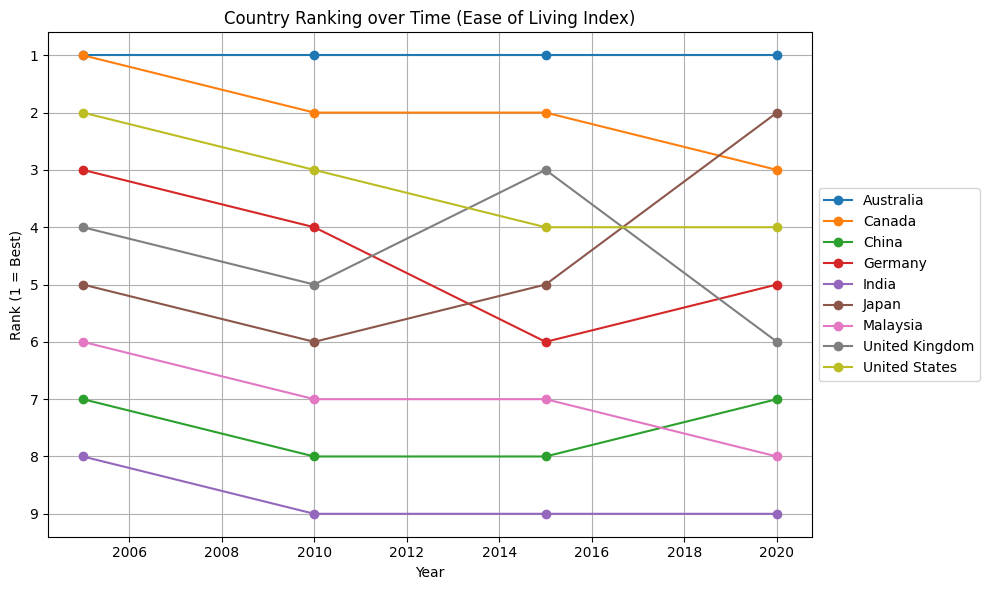

In [17]:
import matplotlib.pyplot as plt

pivot_df = df_selected.pivot(index='Year', columns='Country', values='Rank')

plt.figure(figsize=(10, 6))

for country in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[country], marker='o', label=country)

plt.gca().invert_yaxis()

plt.xlabel("Year")
plt.ylabel("Rank (1 = Best)")
plt.title("Country Ranking over Time (Ease of Living Index)")

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid(True)

# Adjust layout so legend fits
plt.tight_layout()

plt.show()

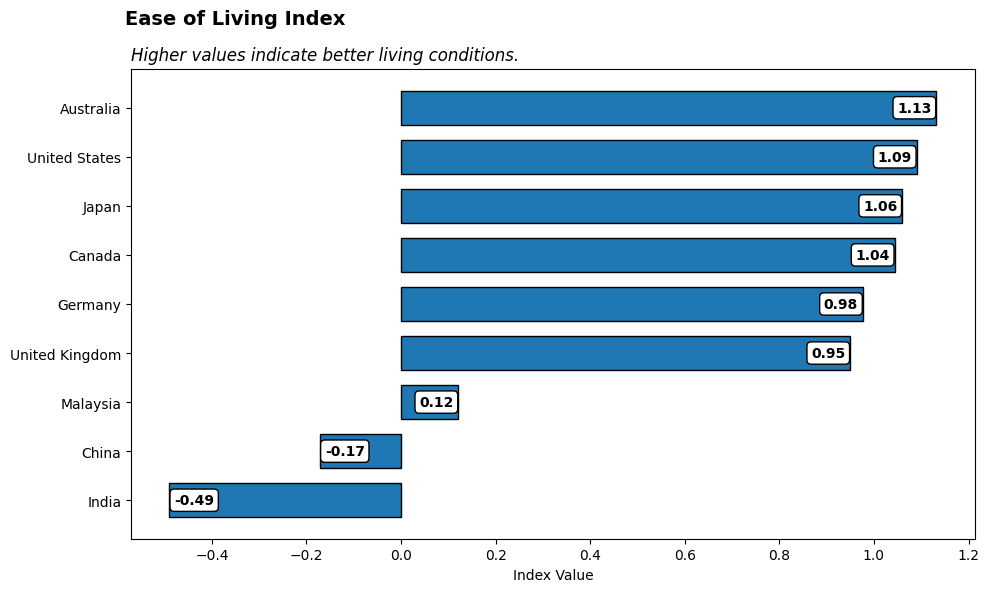

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file_path = 'All_Index_ranking.csv'
data1 = pd.read_csv(file_path)

# Clean column names
data1.columns = data1.columns.str.strip().str.replace(' ', '_')

# Selected countries
selected_countries = [
    "India", "United States", "China", "Australia",
    "Malaysia", "Canada", "Germany", "United Kingdom", "Japan"
]

filtered_df = data1[data1['Country'].isin(selected_countries)]

# Average Ease of Living Index
avg_ease_living = filtered_df.groupby('Country')['Ease_of_Living_Index'].mean()

# Sort values
avg_ease_living = avg_ease_living.sort_values()

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    avg_ease_living.index,
    avg_ease_living.values,
    edgecolor='black',
    height=0.7
)

# Title + subtitle
plt.suptitle('Ease of Living Index', fontsize=14, weight='bold', ha='left', x=0.13)
plt.text(0.0, 1.02, "Higher values indicate better living conditions.", 
         fontsize=12, style='italic', ha='left', transform=plt.gca().transAxes)

plt.xlabel('Index Value')

# ✅ Correct value labels logic
for index, value in enumerate(avg_ease_living):
    # Decide position dynamically
    x_pos = value - 0.01 if value > 0 else value + 0.01
    align = 'right' if value > 0 else 'left'

    plt.text(
        x_pos,
        index,
        f'{value:.2f}',
        va='center',
        ha=align,
        fontsize=10,
        weight='bold',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

plt.tight_layout()

plt.savefig(
    "ease_of_living_plot.png",
    dpi=300,              # high resolution
    bbox_inches='tight'   # removes extra whitespace
)

plt.show()


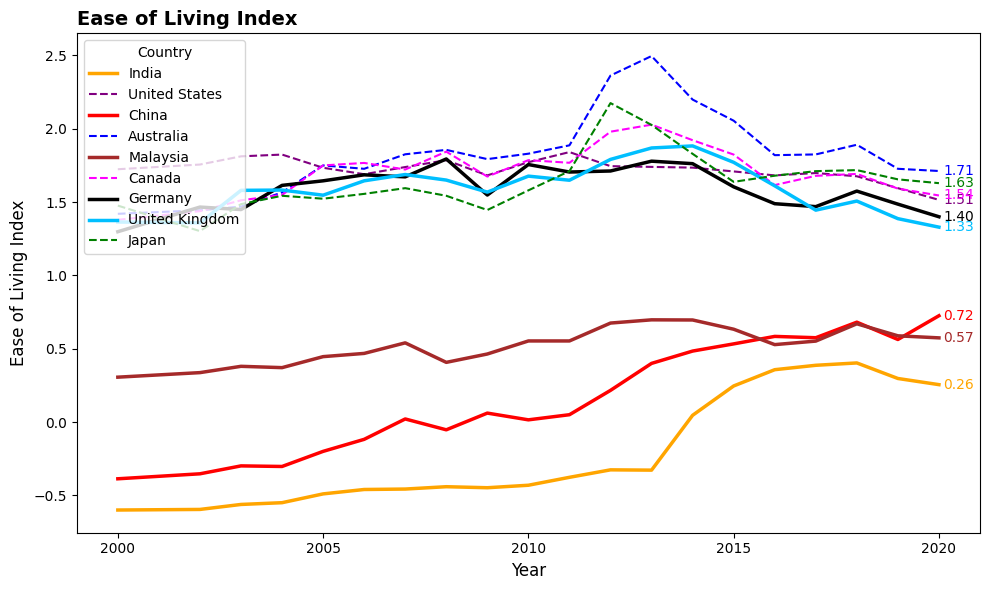

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file_path = 'All_Index_ranking.csv'
data1 = pd.read_csv(file_path)

# Clean column names
data1.columns = data1.columns.str.strip().str.replace(' ', '_')

# Filter years
filtered_df = data1[(data1['Year'] >= 2000) & (data1['Year'] <= 2020)]

# Selected countries
selected_countries = [
    "India", "United States", "China", "Australia",
    "Malaysia", "Canada", "Germany", "United Kingdom", "Japan"
]

# Define colors for highlighted countries
highlighted_countries = {
    "United Kingdom": "deepskyblue",
    "India": "orange",
    "China": "red",
    "Malaysia": "brown",
    "Germany": "black"
}

# Colors for other countries
bright_colors = ["purple", "blue", "fuchsia", "green"]
color_index = 0

# Create figure
plt.figure(figsize=(10, 6))

# Plot each country's data
for country in selected_countries:
    df_country = filtered_df[filtered_df['Country'] == country].sort_values('Year')
    
    if df_country.empty:
        continue

    if country in highlighted_countries:
        line_color = highlighted_countries[country]
        plt.plot(
            df_country['Year'],
            df_country['Ease_of_Living_Index'],
            label=country,
            linewidth=2.5,
            color=line_color
        )

    else:
        line_color = bright_colors[color_index]
        plt.plot(
            df_country['Year'],
            df_country['Ease_of_Living_Index'],
            label=country,
            linewidth=1.5,
            linestyle='--',
            color=line_color
        )
        color_index = (color_index + 1) % len(bright_colors)

    # Add latest value label
    latest_year = df_country['Year'].iloc[-1]
    latest_value = df_country['Ease_of_Living_Index'].iloc[-1]

    plt.text(
        latest_year + 0.1,
        latest_value,
        f'{latest_value:.2f}',
        fontsize=10,
        color=line_color,
        va='center'
    )

# Labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Ease of Living Index', fontsize=12)
plt.title('Ease of Living Index', fontsize=14, weight='bold', ha='left', x=0)

# X-axis ticks
plt.xticks(range(2000, 2022, 5), fontsize=10)

# Legend
plt.legend(title="Country", loc='upper left')

# Layout and save
plt.tight_layout()
plt.savefig("ease_of_living_line_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Ensure Year is integer
data1['Year'] = data1['Year'].astype(int)

# Keep only 5-year intervals
df_5yr = data1[data1['Year'] % 5 == 0].copy()

# Rank countries within each year
df_5yr['Rank'] = (
    df_5yr.groupby('Year')['Ease_of_Living_Index']
    .rank(ascending=False, method='dense')
)

# Select top 20 countries per year
top20 = df_5yr[df_5yr['Rank'] <= 20]

# Sort nicely
top20 = top20.sort_values(['Year', 'Rank'])

# Display
print(top20[['Year', 'Country', 'Ease_of_Living_Index', 'Rank']])

      Year               Country  Ease_of_Living_Index  Rank
268   1975           Switzerland                 0.310   1.0
250   1975                Sweden                 0.254   2.0
287   1975               Denmark                 0.254   2.0
253   1975                 Qatar                 0.193   3.0
2183  1975           Puerto Rico                 0.177   4.0
...    ...                   ...                   ...   ...
6849  2020               Belgium                 1.393  16.0
6844  2020  United Arab Emirates                 1.389  17.0
6840  2020               Austria                 1.385  18.0
6855  2020                Israel                 1.372  19.0
6866  2020        United Kingdom                 1.329  20.0

[204 rows x 4 columns]


In [39]:
pivot_index = top20.pivot(index='Rank', columns='Year', values='Country')
print(pivot_index)

Year                       1975                  1980  \
Rank                                                    
1                   Switzerland                France   
2                        Sweden           Netherlands   
3                       Denmark               Denmark   
4                         Qatar               Germany   
5                   Puerto Rico               Bermuda   
6                     Euro area              Slovenia   
7                       Bermuda           Switzerland   
8                        Norway           Puerto Rico   
9                     Australia                Norway   
10                      Iceland               Belgium   
11                       Poland         United States   
12                      Belgium               Austria   
13                North America                Sweden   
14                       Canada                 Qatar   
15               United Kingdom        United Kingdom   
16                    Lithuania

In [40]:
latex_table = pivot_table.to_latex()
print(latex_table)

\begin{tabular}{lllllllllll}
\toprule
Year & 1975 & 1980 & 1985 & 1990 & 1995 & 2000 & 2005 & 2010 & 2015 & 2020 \\
Rank &  &  &  &  &  &  &  &  &  &  \\
\midrule
1 & Switzerland & France & Iceland & Switzerland & Denmark & United States & Canada & Norway & Switzerland & Switzerland \\
2 & Sweden & Netherlands & Norway & Cayman Islands & United States & Switzerland & Australia & Switzerland & Norway & Norway \\
3 & Denmark & Denmark & Canada & United States & Switzerland & Norway & United States & Denmark & Australia & Singapore \\
4 & Qatar & Germany & Sweden & Liechtenstein & Norway & Qatar & Switzerland & Ireland & Singapore & Australia \\
5 & Puerto Rico & Bermuda & Switzerland & Denmark & Netherlands & Denmark & Norway & Australia & Denmark & Iceland \\
6 & Euro area & Slovenia & Netherlands & Germany & Germany & Netherlands & Finland & Canada & New Zealand & Japan \\
7 & Bermuda & Switzerland & Australia & Norway & Japan & Japan & Netherlands & United States & Canada & Denmark \\

In [2]:
import pandas as pd
import numpy as np

# ============================================================
# Sensitivity Analysis for Global Ease of Living Index Weights
# ============================================================

# Load your final ranking file
file_path = "All_Index_ranking.csv"
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# -----------------------------
# Helper function to find columns
# -----------------------------
def find_col(df, possible_names):
    for col in possible_names:
        if col in df.columns:
            return col
    raise KeyError(
        f"None of these columns were found: {possible_names}\n"
        f"Available columns are:\n{list(df.columns)}"
    )

# Identify required columns from your existing dataset
country_col = find_col(df, ["Country", "country"])
year_col = find_col(df, ["Year", "year"])

economic_col = find_col(df, [
    "Econ_Index", "Economic_Index", "Economic_Index_FA", "Economic_index_FA"
])

institutional_col = find_col(df, [
    "Institutional_Index", "Institutional_Index_FA", "Institutional_index_FA"
])

quality_col = find_col(df, [
    "Quality_Of_Life_Index_FA", "Quality_of_Life_Index_FA",
    "Quality_Of_Life_Index", "Quality_of_Life_Index"
])

sustainability_col = find_col(df, [
    "Sustainability_Index_FA", "Sustainability_index_FA",
    "Sustainability_Index", "Sustainability_index"
])

# Keep only required columns
required_cols = [
    country_col, year_col,
    economic_col, institutional_col, quality_col, sustainability_col
]

df = df[required_cols].copy()
df = df.dropna(subset=[economic_col, institutional_col, quality_col, sustainability_col])

# Ensure Year is numeric
df[year_col] = df[year_col].astype(int)

# -------------------------------------------------
# Define original and alternative weighting schemes
# -------------------------------------------------
weight_schemes = {
    "Baseline_25_25_35_15": {
        "Economic": 0.25,
        "Institutional": 0.25,
        "Quality_of_Life": 0.35,
        "Sustainability": 0.15
    },
    "Scenario_1_20_30_30_20": {
        "Economic": 0.20,
        "Institutional": 0.30,
        "Quality_of_Life": 0.30,
        "Sustainability": 0.20
    },
    "Scenario_2_15_30_25_30": {
        "Economic": 0.15,
        "Institutional": 0.30,
        "Quality_of_Life": 0.25,
        "Sustainability": 0.30
    },
    "Scenario_3_25_25_25_25": {
        "Economic": 0.25,
        "Institutional": 0.25,
        "Quality_of_Life": 0.25,
        "Sustainability": 0.25
    },
    "Scenario_4_30_15_20_35": {
        "Economic": 0.30,
        "Institutional": 0.15,
        "Quality_of_Life": 0.20,
        "Sustainability": 0.35
    }
}

# ---------------------------------------------
# Calculate new EoLI score and rank for each set
# ---------------------------------------------
all_results = []

scheme_order = list(weight_schemes.keys())

for scheme_name, weights in weight_schemes.items():    
    temp = df.copy()
    
    temp["Weight_Scheme"] = scheme_name
    temp["Economic_Weight"] = weights["Economic"]
    temp["Institutional_Weight"] = weights["Institutional"]
    temp["Quality_of_Life_Weight"] = weights["Quality_of_Life"]
    temp["Sustainability_Weight"] = weights["Sustainability"]
    
    # Weighted Global EoLI score
    temp["Sensitivity_EoLI_Score"] = (
        weights["Economic"] * temp[economic_col] +
        weights["Institutional"] * temp[institutional_col] +
        weights["Quality_of_Life"] * temp[quality_col] +
        weights["Sustainability"] * temp[sustainability_col]
    )
    
    # Rank countries within each year
    # Higher score = better rank
    temp["Sensitivity_EoLI_Rank"] = (
        temp.groupby(year_col)["Sensitivity_EoLI_Score"]
        .rank(ascending=False, method="dense")
        .astype(int)
    )
    
    all_results.append(temp)

sensitivity_results = pd.concat(all_results, ignore_index=True)

# -------------------------------------------------
# Add rank change compared with the baseline weights
# -------------------------------------------------
baseline = sensitivity_results[
    sensitivity_results["Weight_Scheme"] == "Baseline_25_25_35_15"
][[country_col, year_col, "Sensitivity_EoLI_Rank"]].rename(
    columns={"Sensitivity_EoLI_Rank": "Baseline_Rank"}
)

sensitivity_results = sensitivity_results.merge(
    baseline,
    on=[country_col, year_col],
    how="left"
)

sensitivity_results["Rank_Change_vs_Baseline"] = (
    sensitivity_results["Sensitivity_EoLI_Rank"] -
    sensitivity_results["Baseline_Rank"]
)

# Interpretation:
# Rank_Change_vs_Baseline < 0 means country rank improved
# Rank_Change_vs_Baseline > 0 means country rank became worse
# Rank_Change_vs_Baseline = 0 means no change

# Save complete results
sensitivity_results.to_csv(
    "Sensitivity_Analysis_All_Country_Rankings.csv",
    index=False
)

print("Saved: Sensitivity_Analysis_All_Country_Rankings.csv")

Saved: Sensitivity_Analysis_All_Country_Rankings.csv


In [6]:
# ============================================================
# 2021 selected-country ranking under each weighting scheme
# ============================================================

selected_countries = [
    "Malaysia", "United States", "China", "Canada", "Germany",
    "Australia", "India", "Japan", "United Kingdom"
]

target_year = 2021

selected_2021 = sensitivity_results[
    (sensitivity_results[country_col].isin(selected_countries)) &
    (sensitivity_results[year_col] == target_year)
].copy()

# Long format table
selected_2021_long = selected_2021[
    [
        year_col, country_col, "Weight_Scheme",
        "Sensitivity_EoLI_Score", "Sensitivity_EoLI_Rank",
        "Baseline_Rank", "Rank_Change_vs_Baseline"
    ]
].sort_values(["Weight_Scheme", "Sensitivity_EoLI_Rank"])

selected_2021_long.to_csv(
    "Sensitivity_Analysis_2021_Selected_Countries_Long.csv",
    index=False
)

print(selected_2021_long)

# Wide format table: easier for paper/reviewer response
selected_2021_wide = selected_2021_long.pivot_table(
    index=country_col,
    columns="Weight_Scheme",
    values="Sensitivity_EoLI_Rank",
    aggfunc="first"
).reset_index()

# Sort by original baseline rank
selected_2021_wide = selected_2021_wide.sort_values(
    "Baseline_25_25_35_15"
)

selected_2021_wide.to_csv(
    "Sensitivity_Analysis_2021_Selected_Countries_Wide.csv",
    index=False
)

print("\nWide ranking table:")
print(selected_2021_wide)


       Year         Country           Weight_Scheme  Sensitivity_EoLI_Score  \
6919   2021       Australia    Baseline_25_25_35_15                 1.74250   
6934   2021           Japan    Baseline_25_25_35_15                 1.67945   
6910   2021          Canada    Baseline_25_25_35_15                 1.47675   
6898   2021   United States    Baseline_25_25_35_15                 1.46595   
6911   2021         Germany    Baseline_25_25_35_15                 1.44980   
6943   2021  United Kingdom    Baseline_25_25_35_15                 1.40820   
6907   2021           China    Baseline_25_25_35_15                 0.72165   
6893   2021        Malaysia    Baseline_25_25_35_15                 0.55685   
6928   2021           India    Baseline_25_25_35_15                 0.45295   
13866  2021       Australia  Scenario_1_20_30_30_20                 1.64290   
13881  2021           Japan  Scenario_1_20_30_30_20                 1.58010   
13857  2021          Canada  Scenario_1_20_30_30_20 

In [5]:
# ============================================================
# Average ranking over the last decade under each weight scheme
# ============================================================

last_decade = range(2011, 2021)

last_decade_results = sensitivity_results[
    (sensitivity_results[country_col].isin(selected_countries)) &
    (sensitivity_results[year_col].isin(last_decade))
].copy()

avg_rankings = (
    last_decade_results
    .groupby([country_col, "Weight_Scheme"])["Sensitivity_EoLI_Rank"]
    .mean()
    .reset_index()
    .rename(columns={"Sensitivity_EoLI_Rank": "Average_Rank_2011_2020"})
)

avg_rankings_wide = avg_rankings.pivot_table(
    index=country_col,
    columns="Weight_Scheme",
    values="Average_Rank_2011_2020",
    aggfunc="first"
).reset_index()

avg_rankings_wide = avg_rankings_wide.sort_values(
    "Baseline_25_25_35_15"
)

avg_rankings_wide.to_csv(
    "Sensitivity_Analysis_Average_Rankings_2011_2020.csv",
    index=False
)

print(avg_rankings_wide)


Weight_Scheme         Country  Baseline_25_25_35_15  Scenario_1_20_30_30_20  \
0                   Australia                   4.0                     3.1   
1                      Canada                   8.6                     6.4   
5                       Japan                   8.6                     8.9   
8               United States                  12.0                    10.5   
7              United Kingdom                  15.4                    15.8   
3                     Germany                  16.2                    15.7   
6                    Malaysia                  41.8                    39.4   
2                       China                  47.4                    48.0   
4                       India                  59.1                    61.4   

Weight_Scheme  Scenario_2_15_30_25_30  Scenario_3_25_25_25_25  \
0                                 2.4                     2.9   
1                                 5.6                     7.4   
5             

In [4]:
import pandas as pd

# ============================================================
# Create Index-wise Rankings for Each Country
# ============================================================

# Input file
file_path = "Ease_Of_Living_Index_Final.csv"

# Load data
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Required columns
required_cols = [
    "Year",
    "Country",
    "Econ_Index",
    "Institutional_Index",
    "Quality_Of_Life_Index_FA",
    "Sustainability_Index_FA",
    "Ease_of_Living_Index"
]

# Check missing columns
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in CSV file: {missing_cols}")

# Convert score columns to numeric
score_cols = [
    "Econ_Index",
    "Institutional_Index",
    "Quality_Of_Life_Index_FA",
    "Sustainability_Index_FA",
    "Ease_of_Living_Index"
]

for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create rankings within each year
# Higher score = better rank
df["Economic_Rank"] = (
    df.groupby("Year")["Econ_Index"]
    .rank(ascending=False, method="dense")
    .astype("Int64")
)

df["Institutional_Rank"] = (
    df.groupby("Year")["Institutional_Index"]
    .rank(ascending=False, method="dense")
    .astype("Int64")
)

df["Quality_of_Life_Rank"] = (
    df.groupby("Year")["Quality_Of_Life_Index_FA"]
    .rank(ascending=False, method="dense")
    .astype("Int64")
)

df["Sustainability_Rank"] = (
    df.groupby("Year")["Sustainability_Index_FA"]
    .rank(ascending=False, method="dense")
    .astype("Int64")
)

df["Global_EoLI_Rank"] = (
    df.groupby("Year")["Ease_of_Living_Index"]
    .rank(ascending=False, method="dense")
    .astype("Int64")
)

# Arrange columns neatly
ranked_df = df[
    [
        "Year",
        "Country",
        "Econ_Index",
        "Economic_Rank",
        "Institutional_Index",
        "Institutional_Rank",
        "Quality_Of_Life_Index_FA",
        "Quality_of_Life_Rank",
        "Sustainability_Index_FA",
        "Sustainability_Rank",
        "Ease_of_Living_Index",
        "Global_EoLI_Rank"
    ]
]

# Sort by year and Global EoLI rank
ranked_df = ranked_df.sort_values(
    by=["Year", "Global_EoLI_Rank"],
    ascending=[True, True]
)

# Save output
ranked_df.to_csv("Ease_Of_Living_Index_Final_With_Ranks.csv", index=False)

print("Ranking file saved as: Ease_Of_Living_Index_Final_With_Ranks.csv")
ranked_df.head(20)

Ranking file saved as: Ease_Of_Living_Index_Final_With_Ranks.csv


,Year,Country,Econ_Index,Economic_Rank,Institutional_Index,Institutional_Rank,Quality_Of_Life_Index_FA,Quality_of_Life_Rank,Sustainability_Index_FA,Sustainability_Rank,Ease_of_Living_Index,Global_EoLI_Rank
34,1970,Netherlands,-0.464000,36,0.50732,1,0.474,11,0.60767,1,0.268,1
1583,1970,Curacao,0.245808,4,0.10979,6,0.073,57,0.06572,44,0.124,2
15,1970,Switzerland,-0.335000,23,-0.38620,74,0.671,2,0.43852,5,0.120,3
62,1970,Belgium,-0.439000,34,-0.16297,33,0.476,10,0.32670,13,0.065,4
1660,1970,Montenegro,-0.276500,21,-0.35375,67,0.508,7,0.24675,16,0.057,5
1685,1970,Russia,-0.367417,26,0.21886,3,0.071,58,0.34236,12,0.039,6
16,1970,Canada,-0.431000,33,-0.27777,49,0.481,9,0.18870,21,0.019,7
1666,1970,North America,-0.545494,52,-0.26266,47,0.554,4,0.17339,25,0.018,8
1678,1970,Puerto Rico,-0.491638,39,-0.21195,40,0.463,12,0.20125,19,0.016,9
25,1970,Cyprus,0.234000,5,-0.32605,61,0.109,52,-0.00056,56,0.015,10


In [5]:
ranking_2021 = ranked_df[ranked_df["Year"] == 2021].copy()

ranking_2021 = ranking_2021[
    [
        "Country",
        "Economic_Rank",
        "Institutional_Rank",
        "Quality_of_Life_Rank",
        "Sustainability_Rank",
        "Global_EoLI_Rank"
    ]
].sort_values("Global_EoLI_Rank")

ranking_2021.to_csv("Ease_Of_Living_Index_Rankings_2021.csv", index=False)

print(ranking_2021)

          Country  Economic_Rank  Institutional_Rank  Quality_of_Life_Rank  \
7777  Switzerland              1                   5                     1   
7742       Norway              2                   4                     2   
7770    Singapore              4                   2                    12   
7793    Australia              7                  10                     5   
7785      Denmark              5                   3                     6   
...           ...            ...                 ...                   ...   
7801       Brazil             74                  68                    68   
7741    Nicaragua             54                  83                    84   
7738        Nepal             84                  77                    85   
7749     Pakistan             86                  80                    87   
7775        Syria             83                  86                    86   

      Sustainability_Rank  Global_EoLI_Rank  
7777             

In [6]:
import pandas as pd

ranking_2021 = ranked_df[ranked_df["Year"] == 2021].copy()

ranking_2021 = ranking_2021[
    [
        "Country",
        "Economic_Rank",
        "Institutional_Rank",
        "Quality_of_Life_Rank",
        "Sustainability_Rank",
        "Global_EoLI_Rank"
    ]
].sort_values("Global_EoLI_Rank")

# Save to CSV
ranking_2021.to_csv("Ease_Of_Living_Index_Rankings_2021.csv", index=False)

# Display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(ranking_2021)

# Optional: reset settings afterwards
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

                     Country  Economic_Rank  Institutional_Rank  \
7777             Switzerland              1                   5   
7742                  Norway              2                   4   
7770               Singapore              4                   2   
7793               Australia              7                  10   
7785                 Denmark              5                   3   
7824               Hong Kong              9                  17   
7804                 Ireland             10                  13   
7810                   Japan              6                  15   
7740             Netherlands             16                   6   
7806                 Iceland              3                   9   
7737             New Zealand             13                   8   
7812             South Korea              8                  22   
7817                 Finland             18                   1   
7774                  Sweden             14                   

In [7]:
selected_countries = [
    "Malaysia",
    "United States",
    "China",
    "Canada",
    "Germany",
    "Australia",
    "India",
    "Japan",
    "United Kingdom"
]

selected_2021 = ranking_2021[
    ranking_2021["Country"].isin(selected_countries)
].copy()

selected_2021.to_csv("Selected_Country_Index_Rankings_2021.csv", index=False)

print(selected_2021)

             Country  Economic_Rank  Institutional_Rank  Quality_of_Life_Rank  \
7793       Australia              7                  10                     5   
7810           Japan              6                  15                    18   
7782          Canada             20                  11                    15   
7767   United States             15                  20                    19   
7784         Germany             27                  12                     9   
7820  United Kingdom             26                  18                    17   
7779           China             21                  50                    63   
7761        Malaysia             53                  38                    54   
7803           India             29                  57                    75   

      Sustainability_Rank  Global_EoLI_Rank  
7793                   32                 4  
7810                   20                 8  
7782                   56                17  
7767 

In [1]:
import pandas as pd
import os

# ============================================================
# Create year-wise and index-wise ranking database
# From: All_Index_ranking.csv
# ============================================================

# Input file
input_file = "All_Index_ranking.csv"

# Read CSV
df = pd.read_csv(input_file)

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# Required index/ranking variables
# ============================================================

rank_columns = [
    "Economic_Rank",
    "Institutional_Rank",
    "Quality_of_Life_Rank",
    "Ease_of_Living_Rank",
    "Sustainability_Rank_x"
]

base_columns = [
    "Year",
    "Country"
]

required_columns = base_columns + rank_columns

# Check missing columns
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"These columns are missing in the CSV file: {missing_columns}")

# Keep only required columns
rank_database = df[required_columns].copy()

# Rename Sustainability_Rank_x to a cleaner name
rank_database = rank_database.rename(
    columns={
        "Sustainability_Rank_x": "Sustainability_Rank"
    }
)

# Convert Year to integer
rank_database["Year"] = rank_database["Year"].astype(int)

# Sort neatly
rank_database = rank_database.sort_values(
    by=["Year", "Ease_of_Living_Rank"],
    ascending=[True, True]
)

# ============================================================
# Create output folders
# ============================================================

main_output_folder = "Index_Ranking_Database"
year_folder = os.path.join(main_output_folder, "Year_Wise")
index_folder = os.path.join(main_output_folder, "Index_Wise")
year_index_folder = os.path.join(main_output_folder, "Year_and_Index_Wise")

os.makedirs(main_output_folder, exist_ok=True)
os.makedirs(year_folder, exist_ok=True)
os.makedirs(index_folder, exist_ok=True)
os.makedirs(year_index_folder, exist_ok=True)

# ============================================================
# 1. Save master ranking database
# ============================================================

master_file = os.path.join(main_output_folder, "All_Years_All_Index_Rankings.csv")
rank_database.to_csv(master_file, index=False)

print(f"Saved master file: {master_file}")

# ============================================================
# 2. Save one CSV for each year
# ============================================================

for year in sorted(rank_database["Year"].unique()):
    
    year_data = rank_database[rank_database["Year"] == year].copy()
    
    year_data = year_data.sort_values(
        by="Ease_of_Living_Rank",
        ascending=True
    )
    
    output_file = os.path.join(
        year_folder,
        f"Index_Rankings_{year}.csv"
    )
    
    year_data.to_csv(output_file, index=False)

print("Saved year-wise CSV files.")

# ============================================================
# 3. Save one CSV for each index/rank variable
# ============================================================

clean_rank_columns = [
    "Economic_Rank",
    "Institutional_Rank",
    "Quality_of_Life_Rank",
    "Ease_of_Living_Rank",
    "Sustainability_Rank"
]

for rank_col in clean_rank_columns:
    
    index_data = rank_database[
        ["Year", "Country", rank_col]
    ].copy()
    
    index_data = index_data.sort_values(
        by=["Year", rank_col],
        ascending=[True, True]
    )
    
    output_file = os.path.join(
        index_folder,
        f"{rank_col}_All_Years.csv"
    )
    
    index_data.to_csv(output_file, index=False)

print("Saved index-wise CSV files.")

# ============================================================
# 4. Save separate CSV for each year and each index
# ============================================================

for year in sorted(rank_database["Year"].unique()):
    
    year_subfolder = os.path.join(year_index_folder, str(year))
    os.makedirs(year_subfolder, exist_ok=True)
    
    year_data = rank_database[rank_database["Year"] == year].copy()
    
    for rank_col in clean_rank_columns:
        
        year_index_data = year_data[
            ["Year", "Country", rank_col]
        ].copy()
        
        year_index_data = year_index_data.sort_values(
            by=rank_col,
            ascending=True
        )
        
        output_file = os.path.join(
            year_subfolder,
            f"{year}_{rank_col}.csv"
        )
        
        year_index_data.to_csv(output_file, index=False)

print("Saved year-and-index-wise CSV files.")

# ============================================================
# Preview
# ============================================================

rank_database.head(20)

Saved master file: Index_Ranking_Database/All_Years_All_Index_Rankings.csv
Saved year-wise CSV files.
Saved index-wise CSV files.
Saved year-and-index-wise CSV files.


,Year,Country,Economic_Rank,Institutional_Rank,Quality_of_Life_Rank,Ease_of_Living_Rank,Sustainability_Rank
1480,1971,Slovenia,3,13,25,1,19
55,1971,Poland,15,9,16,2,18
1427,1971,Lithuania,16,16,7,3,26
1366,1971,Curacao,5,2,59,5,78
1365,1971,Cuba,6,6,54,6,24
1348,1971,Belarus,59,7,13,7,7
13,1971,Sweden,83,98,1,8,1
51,1971,Iceland,62,3,10,9,41
22,1971,Switzerland,69,20,2,10,67
0,1971,Qatar,36,1,58,11,4


In [10]:
import pandas as pd
import numpy as np

# ============================================================
# Rank each world index in Global_Data.csv
# ============================================================

input_file = "Global_Data.csv"
output_file = "Global_Data_With_Index_Ranks.csv"

# Load dataset
df = pd.read_csv(input_file)

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# Index columns from your dataset
# ============================================================

index_columns = {
    "Gini index [SI.POV.GINI] - 2021 [YR2021]": {
        "rank_name": "Gini_Index_Rank",
        "higher_is_better": False
    },
    "Price level index (GDP) [PA.NUS.GDP.PLI] - 2021 [YR2021]": {
        "rank_name": "Price_Level_Index_Rank",
        "higher_is_better": False
    },
    "Consumer price index (2010 = 100) [FP.CPI.TOTL] - 2021 [YR2021]": {
        "rank_name": "Consumer_Price_Index_Rank",
        "higher_is_better": False
    },
    "Total natural resources rents (% of GDP) [NY.GDP.TOTL.RT.ZS] - 2021 [YR2021]": {
        "rank_name": "Natural_Resources_Rents_Rank",
        "higher_is_better": False
    },
    "UHC service coverage index [SH_UHC_SCI] - 2021 [YR2021]": {
        "rank_name": "UHC_Service_Coverage_Rank",
        "higher_is_better": True
    }
}

# ============================================================
# Check required columns
# ============================================================

required_columns = ["Country Name", "Country Code"] + list(index_columns.keys())

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing columns in Global_Data.csv: {missing_columns}")

# ============================================================
# Clean numeric values
# ============================================================

for col in index_columns.keys():
    df[col] = (
        df[col]
        .replace("..", np.nan)
        .replace("", np.nan)
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# Create rankings
# Rank 1 = best country for that index
# ============================================================

for col, info in index_columns.items():
    
    rank_name = info["rank_name"]
    higher_is_better = info["higher_is_better"]
    
    df[rank_name] = df[col].rank(
        ascending=not higher_is_better,
        method="dense",
        na_option="bottom"
    ).astype("Int64")

# ============================================================
# Add year column
# ============================================================

df.insert(0, "Year", 2021)

# ============================================================
# Create simple output table
# ============================================================

rank_output = df[
    [
        "Year",
        "Country Name",
        "Country Code",
        
        "Gini index [SI.POV.GINI] - 2021 [YR2021]",
        "Gini_Index_Rank",
        
        "Price level index (GDP) [PA.NUS.GDP.PLI] - 2021 [YR2021]",
        "Price_Level_Index_Rank",
        
        "Consumer price index (2010 = 100) [FP.CPI.TOTL] - 2021 [YR2021]",
        "Consumer_Price_Index_Rank",
        
        "Total natural resources rents (% of GDP) [NY.GDP.TOTL.RT.ZS] - 2021 [YR2021]",
        "Natural_Resources_Rents_Rank",
        
        "UHC service coverage index [SH_UHC_SCI] - 2021 [YR2021]",
        "UHC_Service_Coverage_Rank"
    ]
].copy()

# Sort by country name
rank_output = rank_output.sort_values("Country Name")

# Save output
rank_output.to_csv(output_file, index=False)

print("Saved ranked file as:")
print(output_file)

print(rank_output.head(20))

Saved ranked file as:
Global_Data_With_Index_Ranks.csv
    Year         Country Name Country Code  \
0   2021          Afghanistan          AFG   
1   2021              Albania          ALB   
2   2021              Algeria          DZA   
3   2021       American Samoa          ASM   
4   2021              Andorra          AND   
5   2021               Angola          AGO   
6   2021  Antigua and Barbuda          ATG   
7   2021            Argentina          ARG   
8   2021              Armenia          ARM   
9   2021                Aruba          ABW   
10  2021            Australia          AUS   
11  2021              Austria          AUT   
12  2021           Azerbaijan          AZE   
13  2021         Bahamas, The          BHS   
14  2021              Bahrain          BHR   
15  2021           Bangladesh          BGD   
16  2021             Barbados          BRB   
17  2021              Belarus          BLR   
18  2021              Belgium          BEL   
19  2021               Be

In [11]:
import pandas as pd

# ============================================================
# Extract selected countries and selected rank columns
# From: Global_Data_With_Index_Ranks.csv
# ============================================================

input_file = "Global_Data_With_Index_Ranks.csv"
output_file = "Selected_Countries_Global_Index_Ranks_2021.csv"

# Load data
df = pd.read_csv(input_file)

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# Countries required
# ============================================================

selected_countries = [
    "Argentina",
    "Australia",
    "Brazil",
    "Canada",
    "China",
    "France",
    "Germany",
    "India",
    "Indonesia",
    "Italy",
    "Japan",
    "Mexico",
    "Saudi Arabia",
    "South Africa",
    "United Kingdom",
    "United States",
    "Russia",
    "South Korea",
    "Turkey"
]

# ============================================================
# Country name cleaning for matching
# ============================================================

def clean_country_name(country):
    country = str(country).strip()

    country_map = {
        "russia": "Russia",
        "Russian Federation": "Russia",
        "Korea, Rep.": "South Korea",
        "Republic of Korea": "South Korea",
        "south korea": "South Korea",
        "Turkiye": "Turkey",
        "Türkiye": "Turkey",
        "turkey": "Turkey",
        "United States of America": "United States",
        "USA": "United States",
        "UK": "United Kingdom"
    }

    return country_map.get(country, country)

df["Country_Clean"] = df["Country Name"].apply(clean_country_name)

# ============================================================
# Required columns
# ============================================================

required_columns = [
    "Year",
    "Country Name",
    "Gini_Index_Rank",
    "Price_Level_Index_Rank",
    "Consumer_Price_Index_Rank",
    "Natural_Resources_Rents_Rank",
    "UHC_Service_Coverage_Rank"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing columns in dataset: {missing_columns}")

# ============================================================
# Filter selected countries
# ============================================================

selected_df = df[df["Country_Clean"].isin(selected_countries)].copy()

# Replace country name with cleaned country name
selected_df["Country"] = selected_df["Country_Clean"]

# Keep only required columns
selected_df = selected_df[
    [
        "Year",
        "Country",
        "Gini_Index_Rank",
        "Price_Level_Index_Rank",
        "Consumer_Price_Index_Rank",
        "Natural_Resources_Rents_Rank",
        "UHC_Service_Coverage_Rank"
    ]
].copy()

# Sort by country name
selected_df = selected_df.sort_values("Country")

# ============================================================
# Check if any selected country is missing
# ============================================================

found_countries = set(selected_df["Country"].unique())
missing_countries = sorted(set(selected_countries) - found_countries)

if missing_countries:
    print("These countries were not found in the dataset:")
    print(missing_countries)

# ============================================================
# Save output
# ============================================================

selected_df.to_csv(output_file, index=False)

print("Saved selected country rank file as:")
print(output_file)

print(selected_df)	Year	Country
1	1971	Qatar

Saved selected country rank file as:
Selected_Countries_Global_Index_Ranks_2021.csv
     Year         Country  Gini_Index_Rank  Price_Level_Index_Rank  \
7    2021       Argentina               58                      84   
10   2021       Australia               68                     191   
26   2021          Brazil               66                     101   
34   2021          Canada               19                     180   
40   2021           China               42                     140   
68   2021          France               21                     167   
73   2021         Germany               29                     169   
88   2021           India               68                      19   
89   2021       Indonesia               41                      43   
95   2021           Italy               37                     161   
97   2021           Japan               68                     177   
127  2021          Mexico               68                     112   
160  2

In [13]:
import pandas as pd

# ============================================================
# Join EoLI rank with selected global index rankings
# ============================================================

eoli_file = "EOLI_Ranking.csv"
global_rank_file = "Selected_Countries_Global_Index_Ranks_2021.csv"

output_file = "Selected_Countries_Global_Index_Ranks_With_EoLI_2021.csv"

# ============================================================
# 1. Load files
# ============================================================

eoli = pd.read_csv(eoli_file)
global_rank = pd.read_csv(global_rank_file)

# Clean column names
eoli.columns = eoli.columns.str.strip()
global_rank.columns = global_rank.columns.str.strip()

# ============================================================
# 2. Keep only required variables from EOLI_Ranking.csv
# ============================================================

required_eoli_cols = ["Year", "Country", "Rank"]

missing_eoli_cols = [col for col in required_eoli_cols if col not in eoli.columns]

if missing_eoli_cols:
    raise ValueError(f"Missing columns in EOLI_Ranking.csv: {missing_eoli_cols}")

eoli = eoli[["Year", "Country", "Rank"]].copy()

# Rename Rank as EoLI_Rank
eoli = eoli.rename(columns={"Rank": "EoLI_Rank"})

# ============================================================
# 3. Clean Year and Country for matching
# ============================================================

def clean_country_name(country):
    country = str(country).strip()

    country_map = {
        "russia": "Russia",
        "Russian Federation": "Russia",
        "Korea, Rep.": "South Korea",
        "Republic of Korea": "South Korea",
        "south korea": "South Korea",
        "Turkiye": "Turkey",
        "Türkiye": "Turkey",
        "turkey": "Turkey",
        "United States of America": "United States",
        "USA": "United States",
        "UK": "United Kingdom"
    }

    return country_map.get(country, country)

eoli["Year"] = pd.to_numeric(eoli["Year"], errors="coerce").astype("Int64")
global_rank["Year"] = pd.to_numeric(global_rank["Year"], errors="coerce").astype("Int64")

eoli["Country"] = eoli["Country"].apply(clean_country_name)
global_rank["Country"] = global_rank["Country"].apply(clean_country_name)

# ============================================================
# 4. Merge using Year and Country
# ============================================================

merged_df = pd.merge(
    global_rank,
    eoli,
    on=["Year", "Country"],
    how="left"
)

# ============================================================
# 5. Arrange columns
# ============================================================

final_df = merged_df[
    [
        "Year",
        "Country",
        "EoLI_Rank",
        "Gini_Index_Rank",
        "Price_Level_Index_Rank",
        "Consumer_Price_Index_Rank",
        "Natural_Resources_Rents_Rank",
        "UHC_Service_Coverage_Rank"
    ]
].copy()

# Sort by EoLI rank
final_df = final_df.sort_values("EoLI_Rank")

# ============================================================
# 6. Check missing EoLI ranks
# ============================================================

missing_eoli = final_df[final_df["EoLI_Rank"].isna()]

if not missing_eoli.empty:
    print("Warning: EoLI rank not found for these countries:")
    print(missing_eoli[["Year", "Country"]])

# ============================================================
# 7. Save output
# ============================================================

final_df.to_csv(output_file, index=False)

print("Saved merged file as:")
print(output_file)

print(final_df)

Saved merged file as:
Selected_Countries_Global_Index_Ranks_With_EoLI_2021.csv
    Year         Country  EoLI_Rank  Gini_Index_Rank  Price_Level_Index_Rank  \
1   2021       Australia          4               68                     191   
10  2021           Japan          8               68                     177   
15  2021     South Korea         12               26                     159   
3   2021          Canada         17               19                     180   
18  2021   United States         18               51                     187   
6   2021         Germany         19               29                     169   
5   2021          France         20               21                     167   
17  2021  United Kingdom         21               24                     179   
9   2021           Italy         28               37                     161   
13  2021    Saudi Arabia         37               68                     118   
4   2021           China         41      